# Stockout / Backorder Prediction

## Objective

Build and evaluate machine-learning models for predicting whether a product
will go on backorder.

The notebook compares:

1. Logistic Regression baseline
2. Random Forest
3. XGBoost
4. Random Forest with SMOTE + Tomek Links
5. XGBoost with SMOTE + Tomek Links

Because the target is highly imbalanced, the primary evaluation metrics are:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

SMOTE and Tomek Links are applied only to the training data.

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [3]:
PROCESSED_DIR = "../data/processed"
MODEL_DIR = "../models"
OUTPUT_DIR = "../outputs"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Paths configured.")

Paths configured.


In [4]:
X_train = np.load(
    os.path.join(PROCESSED_DIR, "X_train.npy")
)

X_valid = np.load(
    os.path.join(PROCESSED_DIR, "X_valid.npy")
)

y_train = np.load(
    os.path.join(PROCESSED_DIR, "y_train.npy")
)

y_valid = np.load(
    os.path.join(PROCESSED_DIR, "y_valid.npy")
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (1350288, 40)
X_valid: (337572, 40)
y_train: (1350288,)
y_valid: (337572,)


In [5]:
print("Training target distribution:")
print(pd.Series(y_train).value_counts())

print("\nValidation target distribution:")
print(pd.Series(y_valid).value_counts())

print("\nTraining backorder rate:")
print(round(y_train.mean() * 100, 4), "%")

print("\nValidation backorder rate:")
print(round(y_valid.mean() * 100, 4), "%")

Training target distribution:
0    1341254
1       9034
Name: count, dtype: int64

Validation target distribution:
0    335313
1      2259
Name: count, dtype: int64

Training backorder rate:
0.669 %

Validation backorder rate:
0.6692 %


In [6]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        ),
        "PR-AUC": average_precision_score(
            y_true,
            y_prob
        )
    }
    
    return metrics

In [7]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training Logistic Regression...
Training complete.


In [8]:
logistic_pred = logistic_model.predict(X_valid)

logistic_prob = logistic_model.predict_proba(
    X_valid
)[:, 1]

logistic_metrics = evaluate_model(
    "Logistic Regression",
    y_valid,
    logistic_pred,
    logistic_prob
)

logistic_metrics

{'Model': 'Logistic Regression',
 'Accuracy': 0.7399813965613262,
 'Precision': 0.01896768967689677,
 'Recall': 0.7463479415670651,
 'F1': 0.03699518360450701,
 'ROC-AUC': np.float64(0.8110669379970681),
 'PR-AUC': np.float64(0.02419167618737675)}

In [9]:
print(
    classification_report(
        y_valid,
        logistic_pred,
        target_names=["No Backorder", "Backorder"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

No Backorder       1.00      0.74      0.85    335313
   Backorder       0.02      0.75      0.04      2259

    accuracy                           0.74    337572
   macro avg       0.51      0.74      0.44    337572
weighted avg       0.99      0.74      0.84    337572



In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Training Random Forest...
Random Forest training complete.


In [11]:
rf_pred = rf_model.predict(X_valid)

rf_prob = rf_model.predict_proba(
    X_valid
)[:, 1]

rf_metrics = evaluate_model(
    "Random Forest",
    y_valid,
    rf_pred,
    rf_prob
)

rf_metrics

{'Model': 'Random Forest',
 'Accuracy': 0.9926089841574538,
 'Precision': 0.4366952789699571,
 'Recall': 0.36033643204957944,
 'F1': 0.39485811302449675,
 'ROC-AUC': np.float64(0.9704797134123229),
 'PR-AUC': np.float64(0.29448239012168925)}

In [12]:
print(
    classification_report(
        y_valid,
        rf_pred,
        target_names=["No Backorder", "Backorder"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

No Backorder       1.00      1.00      1.00    335313
   Backorder       0.44      0.36      0.39      2259

    accuracy                           0.99    337572
   macro avg       0.72      0.68      0.70    337572
weighted avg       0.99      0.99      0.99    337572



In [13]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training complete.")

Training XGBoost...
XGBoost training complete.


In [14]:
xgb_pred = xgb_model.predict(X_valid)

xgb_prob = xgb_model.predict_proba(
    X_valid
)[:, 1]

xgb_metrics = evaluate_model(
    "XGBoost",
    y_valid,
    xgb_pred,
    xgb_prob
)

xgb_metrics

{'Model': 'XGBoost',
 'Accuracy': 0.9934976834571587,
 'Precision': 0.7105263157894737,
 'Recall': 0.04780876494023904,
 'F1': 0.08958938199917046,
 'ROC-AUC': np.float64(0.9607613550454528),
 'PR-AUC': np.float64(0.2793997325039253)}

In [15]:
print(
    classification_report(
        y_valid,
        xgb_pred,
        target_names=["No Backorder", "Backorder"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

No Backorder       0.99      1.00      1.00    335313
   Backorder       0.71      0.05      0.09      2259

    accuracy                           0.99    337572
   macro avg       0.85      0.52      0.54    337572
weighted avg       0.99      0.99      0.99    337572



In [16]:
baseline_results = pd.DataFrame([
    logistic_metrics,
    rf_metrics,
    xgb_metrics
])

baseline_results = baseline_results.sort_values(
    "PR-AUC",
    ascending=False
)

display(
    baseline_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Random Forest,0.9926,0.4367,0.3603,0.3949,0.9705,0.2945
2,XGBoost,0.9935,0.7105,0.0478,0.0896,0.9608,0.2794
0,Logistic Regression,0.7400,0.0190,0.7463,0.0370,0.8111,0.0242


In [18]:
from imblearn.combine import SMOTETomek

print("Original training shape:")
print(X_train.shape)

print("\nOriginal class distribution:")
print(pd.Series(y_train).value_counts())

# Use a controlled subset for SMOTE/Tomek experimentation.
# The original training data remains untouched.
MAX_SMOTE_SAMPLES = 300_000

if len(X_train) > MAX_SMOTE_SAMPLES:
    rng = np.random.RandomState(RANDOM_STATE)

    # Keep all positive/backorder samples
    positive_idx = np.where(y_train == 1)[0]

    # Randomly sample negative examples
    negative_idx = np.where(y_train == 0)[0]

    negative_sample_size = (
        MAX_SMOTE_SAMPLES - len(positive_idx)
    )

    sampled_negative_idx = rng.choice(
        negative_idx,
        size=negative_sample_size,
        replace=False
    )

    selected_idx = np.concatenate([
        positive_idx,
        sampled_negative_idx
    ])

    rng.shuffle(selected_idx)

    X_smote_input = X_train[selected_idx]
    y_smote_input = y_train[selected_idx]

else:
    X_smote_input = X_train
    y_smote_input = y_train

print("\nSMOTE/Tomek input shape:")
print(X_smote_input.shape)

print("\nSMOTE/Tomek input distribution:")
print(pd.Series(y_smote_input).value_counts())

# Apply SMOTE + Tomek
smote_tomek = SMOTETomek(
    random_state=RANDOM_STATE,
    n_jobs=1
)

print("\nApplying SMOTE + Tomek Links...")

X_train_balanced, y_train_balanced = smote_tomek.fit_resample(
    X_smote_input,
    y_smote_input
)

print("\nBalanced training shape:")
print(X_train_balanced.shape)

print("\nBalanced class distribution:")
print(pd.Series(y_train_balanced).value_counts())

Original training shape:
(1350288, 40)

Original class distribution:
0    1341254
1       9034
Name: count, dtype: int64

SMOTE/Tomek input shape:
(300000, 40)

SMOTE/Tomek input distribution:
0    290966
1      9034
Name: count, dtype: int64

Applying SMOTE + Tomek Links...

Balanced training shape:
(580100, 40)

Balanced class distribution:
0    290050
1    290050
Name: count, dtype: int64


In [19]:
balance_df = pd.DataFrame({
    "Class": ["No Backorder", "Backorder"],
    "Before": [
        np.sum(y_train == 0),
        np.sum(y_train == 1)
    ],
    "After": [
        np.sum(y_train_balanced == 0),
        np.sum(y_train_balanced == 1)
    ]
})

display(balance_df)

,Class,Before,After
0,No Backorder,1341254,290050
1,Backorder,9034,290050


In [20]:
rf_smote_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=2,
    class_weight=None,
    n_jobs=1,
    random_state=RANDOM_STATE
)

print("Training balanced Random Forest...")

rf_smote_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Training complete.")

Training balanced Random Forest...
Training complete.


In [21]:
rf_smote_pred = rf_smote_model.predict(X_valid)

rf_smote_prob = rf_smote_model.predict_proba(
    X_valid
)[:, 1]

rf_smote_metrics = evaluate_model(
    "Random Forest + SMOTE/Tomek",
    y_valid,
    rf_smote_pred,
    rf_smote_prob
)

print(rf_smote_metrics)

{'Model': 'Random Forest + SMOTE/Tomek', 'Accuracy': 0.9601359117462349, 'Precision': 0.1179721615720524, 'Recall': 0.7653829127932713, 'F1': 0.20443393437777121, 'ROC-AUC': np.float64(0.9675178200333557), 'PR-AUC': np.float64(0.2730928550702557)}


In [22]:
print(
    classification_report(
        y_valid,
        rf_smote_pred,
        target_names=["No Backorder", "Backorder"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

No Backorder       1.00      0.96      0.98    335313
   Backorder       0.12      0.77      0.20      2259

    accuracy                           0.96    337572
   macro avg       0.56      0.86      0.59    337572
weighted avg       0.99      0.96      0.97    337572



In [23]:
# ============================================
# XGBoost with SMOTE + Tomek Links
# ============================================

print("Training XGBoost on SMOTE + Tomek data...")

xgb_smote = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=1,
    random_state=42
)

xgb_smote.fit(X_train_balanced, y_train_balanced)

print("XGBoost training completed.")

Training XGBoost on SMOTE + Tomek data...
XGBoost training completed.


In [25]:
# ============================================
# Evaluate XGBoost + SMOTE/Tomek
# ============================================

# Generate predictions
xgb_smote_pred = xgb_smote.predict(X_valid)

# Generate probabilities for positive class
xgb_smote_prob = xgb_smote.predict_proba(X_valid)[:, 1]

# Evaluate
xgb_smote_metrics = evaluate_model(
    "XGBoost + SMOTE/Tomek",
    y_valid,
    xgb_smote_pred,
    xgb_smote_prob
)

print("\nXGBoost Classification Report:\n")

print(
    classification_report(
        y_valid,
        xgb_smote_pred,
        target_names=["No Backorder", "Backorder"],
        zero_division=0
    )
)


XGBoost Classification Report:

              precision    recall  f1-score   support

No Backorder       1.00      0.95      0.97    335313
   Backorder       0.09      0.73      0.15      2259

    accuracy                           0.95    337572
   macro avg       0.54      0.84      0.56    337572
weighted avg       0.99      0.95      0.97    337572



In [ ]:
# ============================================
# Compare RF vs XGBoost
# ============================================

comparison = pd.DataFrame([
    rf_smote_metrics,
    xgb_smote_metrics
])

display(comparison)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest + SMOTE/Tomek,0.960136,0.117972,0.765383,0.204434,0.967518,0.273093
1,XGBoost + SMOTE/Tomek,0.945455,0.085242,0.734838,0.152763,0.948166,0.173659



Random Forest + SMOTE/Tomek
Accuracy       : 0.960136
Precision      : 0.117972
Recall         : 0.765383
F1             : 0.204434
ROC-AUC        : 0.967518
PR-AUC         : 0.273093

XGBoost + SMOTE/Tomek
Accuracy       : 0.945455
Precision      : 0.085242
Recall         : 0.734838
F1             : 0.152763
ROC-AUC        : 0.948166
PR-AUC         : 0.173659


Confusion Matrix:
[[322386  12927]
 [   530   1729]]


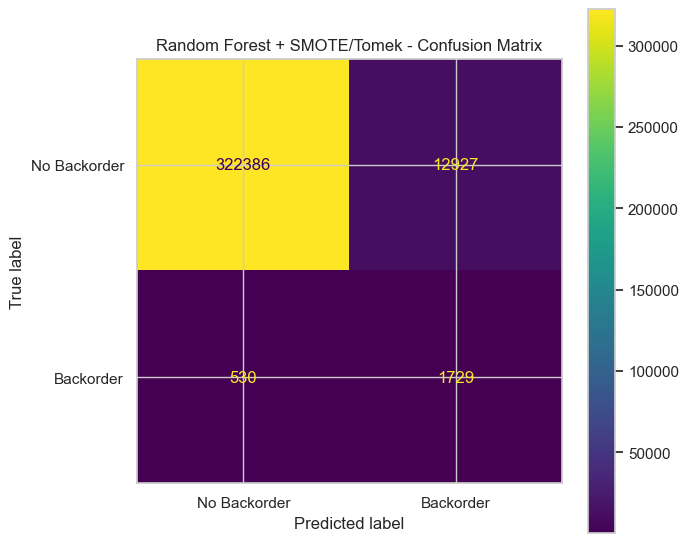

In [29]:

# ============================================
# Confusion Matrix - Final Random Forest
# ============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, rf_smote_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Backorder", "Backorder"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")

ax.set_title("Random Forest + SMOTE/Tomek - Confusion Matrix")
plt.tight_layout()
plt.show()

In [39]:
# ============================================
# Feature Importance
# ============================================

import pandas as pd
import joblib

preprocessor = joblib.load(
    "../models/stockout_preprocessor.joblib"
)

feature_names = preprocessor.get_feature_names_out()
importances = rf_smote.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Features:")
display(feature_importance_df.head(20))


Top 20 Features:


,Feature,Importance
20,num__inventory_gap,0.162826
3,num__forecast_3_month,0.084119
27,num__inventory_coverage,0.083435
0,num__national_inv,0.080715
4,num__forecast_6_month,0.072584
5,num__forecast_9_month,0.058877
24,num__forecast_growth_6m,0.049171
19,num__forecast_vs_sales,0.048306
21,num__demand_pressure,0.035451
18,num__inventory_to_forecast,0.033548


In [41]:
# ============================================
# Save Final Stockout Prediction Model
# ============================================

import joblib
import os

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save final Random Forest
joblib.dump(
    rf_smote,
    os.path.join(MODEL_DIR, "final_stockout_model.joblib")
)

# Save preprocessing pipeline
joblib.dump(
    preprocessor,
    os.path.join(MODEL_DIR, "stockout_preprocessor.joblib")
)

print("============================================")
print("FINAL MODEL FILES SAVED")
print("============================================")
print("✓ final_stockout_model.joblib")
print("✓ stockout_preprocessor.joblib")
print("============================================")

FINAL MODEL FILES SAVED
✓ final_stockout_model.joblib
✓ stockout_preprocessor.joblib


In [43]:
# ============================================
# Load Final Stockout Model
# ============================================

import joblib
import os

MODEL_DIR = "../models"

final_model = joblib.load(
    os.path.join(MODEL_DIR, "final_stockout_model.joblib")
)

final_preprocessor = joblib.load(
    os.path.join(MODEL_DIR, "stockout_preprocessor.joblib")
)

print("✓ Final model loaded")
print("✓ Preprocessor loaded")

✓ Final model loaded
✓ Preprocessor loaded


In [44]:
# ============================================
# Verify Saved Model
# ============================================

saved_predictions = final_model.predict(X_valid)

saved_probabilities = final_model.predict_proba(X_valid)[:, 1]

print("Prediction test successful!")
print()
print("Number of predictions:", len(saved_predictions))
print("Minimum probability:", saved_probabilities.min())
print("Maximum probability:", saved_probabilities.max())
print("Average probability:", saved_probabilities.mean())

Prediction test successful!

Number of predictions: 337572
Minimum probability: 0.0
Maximum probability: 0.9973333333333333
Average probability: 0.06746895552796285


In [45]:
# ============================================
# Single Product Risk Test
# ============================================

sample_X = X_valid[0:1]

risk_probability = final_model.predict_proba(sample_X)[0, 1]

risk_prediction = final_model.predict(sample_X)[0]

print("============================================")
print("STOCKOUT RISK PREDICTION")
print("============================================")

print(f"Risk Probability : {risk_probability:.4f}")
print(f"Risk Percentage  : {risk_probability * 100:.2f}%")

if risk_probability >= 0.70:
    risk_level = "HIGH"
elif risk_probability >= 0.30:
    risk_level = "MEDIUM"
else:
    risk_level = "LOW"

print(f"Risk Level       : {risk_level}")
print(f"Model Prediction : {'BACKORDER' if risk_prediction == 1 else 'NO BACKORDER'}")

STOCKOUT RISK PREDICTION
Risk Probability : 0.5161
Risk Percentage  : 51.61%
Risk Level       : MEDIUM
Model Prediction : BACKORDER
